Acceptance rate distribution_1: 0.7057057057057057
Acceptance rate distribution_2: 0.6106106106106106
Acceptance rate distribution_3: 0.6516516516516516


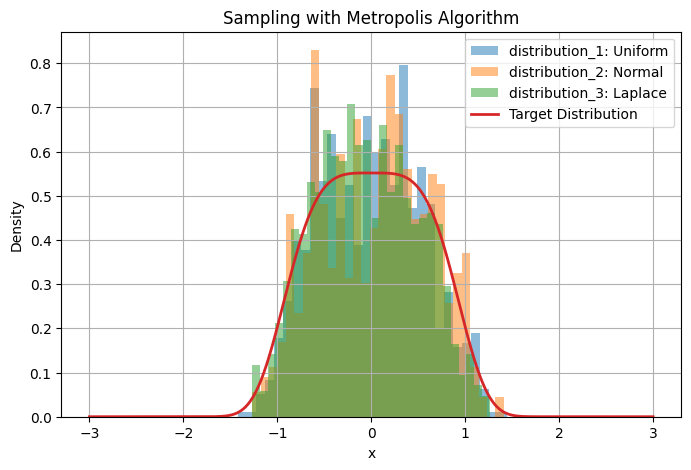

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

# =========================
# Metropolis Algorithm
# =========================

def target_distribution(x):
    """
    Target distribution:
        pi(x) ∝ exp(-x^4)

    The normalizing constant is not needed because it cancels out
    in the ratio pi(y) / pi(x).
    """
    return np.exp(-x**4)


# =========================
# Proposal Distributions
# =========================

def distribution_1(x_current, step_size):
    """
    Symmetric uniform proposal:
        y ~ U[x - step_size, x + step_size]
    """
    return np.random.uniform(
        x_current - step_size,
        x_current + step_size
    )


def distribution_2(x_current, step_size):
    """
    Symmetric normal proposal:
        y ~ N(x_current, step_size^2)

    Generated manually using Box-Muller transform.
    """

    u1 = np.random.uniform(0, 1)
    u2 = np.random.uniform(0, 1)

    z = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)

    return x_current + step_size * z


def distribution_3(x_current, step_size):
    """
    Symmetric Laplace proposal.

    Generated manually using inverse transform sampling.
    """

    u = np.random.uniform(-0.5, 0.5)

    epsilon = -step_size * np.sign(u) * np.log(1 - 2 * abs(u))

    return x_current + epsilon


# =========================
# Metropolis Algorithm
# =========================

def metropolis_algorithm(
    n,
    proposal_distribution,
    x0=0,
    step_size=1
):
    """
    n: number of samples
    x0: initial value
    step_size: proposal width
    proposal_distribution:
        distribution_1,
        distribution_2,
        distribution_3
    """

    samples = np.zeros(n)
    samples[0] = x0

    accepted = 0

    for i in range(1, n):

        x_current = samples[i - 1]

        # Generate candidate
        y = proposal_distribution(x_current, step_size)

        # Compute acceptance ratio
        alpha = min(
            1,
            target_distribution(y) / target_distribution(x_current)
        )

        # Accept or reject
        u = np.random.uniform(0, 1)

        if u < alpha:
            samples[i] = y
            accepted += 1
        else:
            samples[i] = x_current

    acceptance_rate = accepted / (n - 1)

    return samples, acceptance_rate


# =========================
# Run the Algorithm
# =========================

np.random.seed(42)

n = 1000

samples_1, acceptance_rate_1 = metropolis_algorithm(
    n=n,
    proposal_distribution=distribution_1,
    x0=0,
    step_size=1
)

samples_2, acceptance_rate_2 = metropolis_algorithm(
    n=n,
    proposal_distribution=distribution_2,
    x0=0,
    step_size=1
)

samples_3, acceptance_rate_3 = metropolis_algorithm(
    n=n,
    proposal_distribution=distribution_3,
    x0=0,
    step_size=0.7
)

print("Acceptance rate distribution_1:", acceptance_rate_1)
print("Acceptance rate distribution_2:", acceptance_rate_2)
print("Acceptance rate distribution_3:", acceptance_rate_3)


# =========================
# Plot Results
# =========================

Z = 0.5 * gamma(1 / 4)

x = np.linspace(-3, 3, 1000)

target = np.exp(-x**4) / Z

plt.figure(figsize=(8, 5))

plt.hist(
    samples_1,
    bins=30,
    density=True,
    alpha=0.5,
    label="distribution_1: Uniform"
)

plt.hist(
    samples_2,
    bins=30,
    density=True,
    alpha=0.5,
    label="distribution_2: Normal"
)

plt.hist(
    samples_3,
    bins=30,
    density=True,
    alpha=0.5,
    label="distribution_3: Laplace"
)

plt.plot(
    x,
    target,
    linewidth=2,
    label="Target Distribution"
)

plt.title("Sampling with Metropolis Algorithm")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()